In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df = pd.read_csv('stocks.csv')
display(df.head())
display(df.info())
print("Tickers in dataset:", df['Ticker'].unique())

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


None

Tickers in dataset: ['AAPL' 'MSFT' 'NFLX' 'GOOG']


### Convert Dates & Sort Chronologically

In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
print("Missing values in the dataset:")
print(df.isnull().sum())

Missing values in the dataset:
Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


### Plot Comparative Closing Prices (Multi-line)

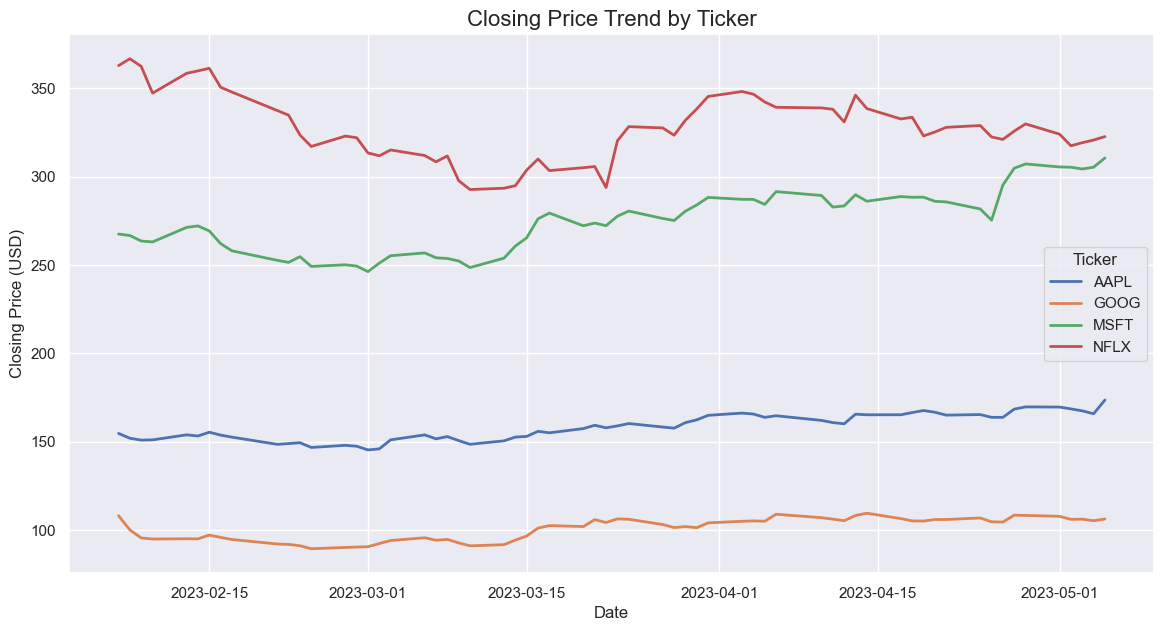

In [10]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Close', hue='Ticker', linewidth=2)
plt.title('Closing Price Trend by Ticker', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.legend(title='Ticker')
plt.show()

### Generate Financial Metric Correlation Heatmap

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


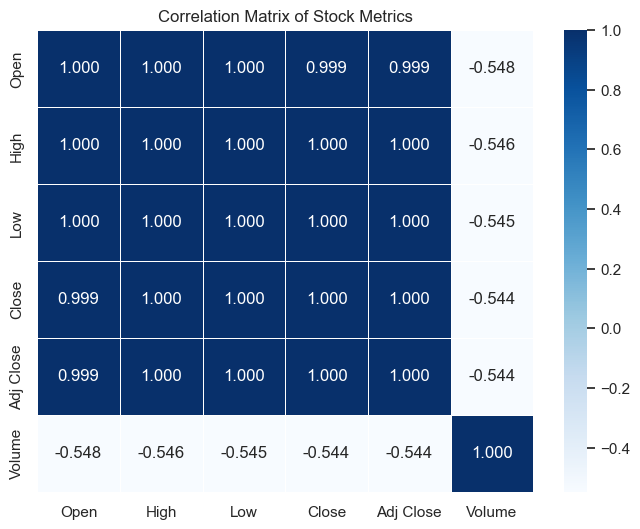

In [9]:
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
display(df[numerical_cols].describe())
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of Stock Metrics')
plt.show()

### Isolate AAPL Data for Volume Bar Chart

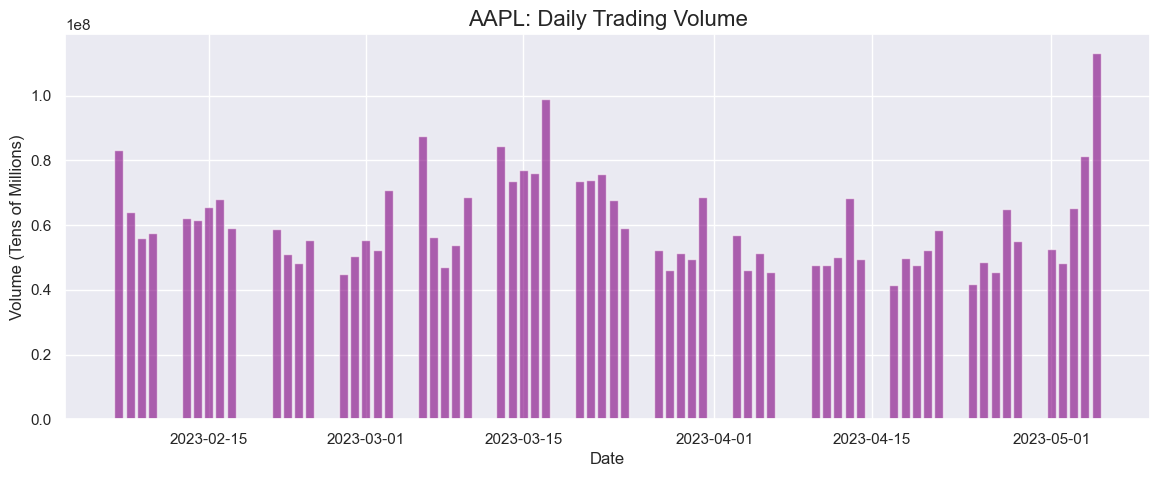

In [8]:
plt.figure(figsize=(14, 5))
plt.bar(aapl_df['Date'], aapl_df['Volume'], color='purple', alpha=0.6)
plt.title('AAPL: Daily Trading Volume', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume (Tens of Millions)', fontsize=12)
plt.show()

### Calculate & Plot AAPL Daily Returns Distribution

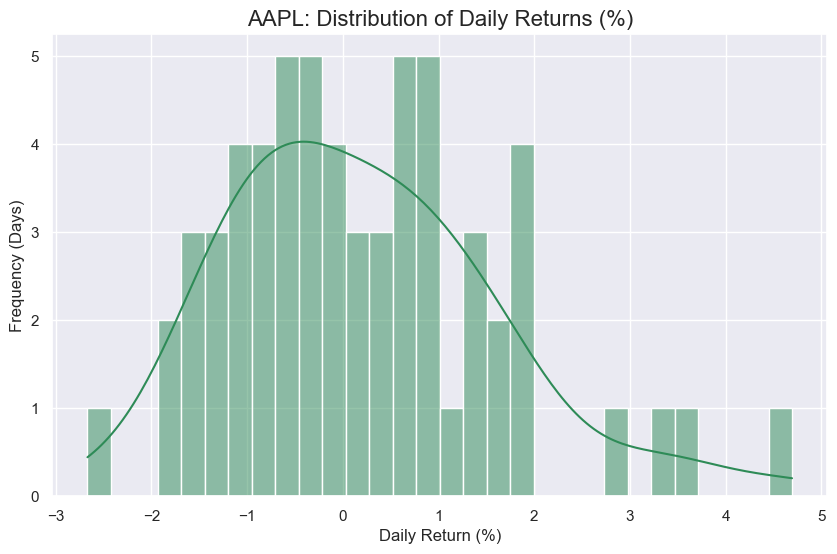

In [7]:
aapl_df['Daily_Return'] = aapl_df['Close'].pct_change() * 100

plt.figure(figsize=(10, 6))
sns.histplot(aapl_df['Daily_Return'].dropna(), bins=30, kde=True, color='seagreen')
plt.title('AAPL: Distribution of Daily Returns (%)', fontsize=16)
plt.xlabel('Daily Return (%)', fontsize=12)
plt.ylabel('Frequency (Days)', fontsize=12)
plt.show()